<a href="https://colab.research.google.com/github/hannaginther/ENGG680_2025_Fall/blob/main/Project/CatBoost_Comparing_Transformations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**CatBoost Gradient Boosted Regression Model for LOS Prediction**
##1. RAW LOS - Small Sample Test

In [ ]:
from google.colab import drive
drive.mount ('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.6 MB/s eta 0:00:00


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib
import json

In [ ]:
# Load df
df_full = pd.read_feather('/content/drive/MyDrive/Sparcs_Datafiles/model_data_v1.feather')

In [ ]:
# Make samle df: 200,000 rows
df_sample = df_full.sample(n=200_000, random_state=42)

In [ ]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200000 entries, 3554536 to 14721
Data columns (total 28 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   health_service_area      200000 non-null  object
 1   hospital_county          200000 non-null  object
 2   facility_id              200000 non-null  object
 3   age_group                200000 non-null  object
 4   zip_code                 200000 non-null  object
 5   gender                   200000 non-null  object
 6   race                     200000 non-null  object
 7   ethnicity                200000 non-null  object
 8   length_of_stay           200000 non-null  int64 
 9   admission_type           200000 non-null  object
 10  discharge_year           200000 non-null  int64 
 11  ccsr_dx_code             200000 non-null  object
 12  ccsr_px_code             200000 non-null  object
 13  apr_drg_code             200000 non-null  object
 14  apr_mdc_code        

In [ ]:
from sklearn.model_selection import train_test_split

# Raw LOS column
y_raw = df_sample['length_of_stay']

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    df_sample.drop(columns=['length_of_stay']),
    y_raw,
    test_size=0.2,
    random_state=42
)

In [ ]:
import numpy as np

# log1p transform (fit on train)
y_train_log = np.log1p(y_train_raw)

# apply to test
y_test_log = np.log1p(y_test_raw)

In [ ]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

# Fit only on training raw LOS
y_train_yj = pt.fit_transform(y_train_raw.values.reshape(-1, 1)).ravel()

# Apply to test
y_test_yj = pt.transform(y_test_raw.values.reshape(-1, 1)).ravel()

In [ ]:
# Save the inverse transformer for later preds
import joblib
joblib.dump(pt, '/content/drive/MyDrive/Sparcs_Datafiles/los_yj_transformer_sample.joblib')

['/content/drive/MyDrive/Sparcs_Datafiles/los_yj_transformer_sample.joblib']

In [ ]:
# Prepare 4 feature sets (T1 through T4)

In [ ]:
# Rebuild final train/test dataframes
train_df = X_train_raw.copy()
train_df['los_raw'] = y_train_raw
train_df['los_log'] = y_train_log
train_df['los_yj'] = y_train_yj

# Reassemble test set
test_df = X_test_raw.copy()
test_df['los_raw'] = y_test_raw
test_df['los_log'] = y_test_log
test_df['los_yj'] = y_test_yj

In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib

# Identify categorical features
cat_features = train_df.select_dtypes(include=['object']).columns.tolist()

# Separate X and y for all target versions
X_train = train_df.drop(columns=['los_raw', 'los_log', 'los_yj'])
X_test = test_df.drop(columns=['los_raw', 'los_log', 'los_yj'])

y_train_raw = train_df['los_raw']
y_test_raw = test_df['los_raw']

y_train_log = train_df['los_log']
y_test_log = test_df['los_log']

y_train_yj = train_df['los_yj']
y_test_yj = test_df['los_yj']

# Create CatBoost pool objectss
train_pool_raw = Pool(X_train, y_train_raw, cat_features=cat_features)
test_pool_raw = Pool(X_test, y_test_raw, cat_features=cat_features)

train_pool_log = Pool(X_train, y_train_log, cat_features=cat_features)
test_pool_log = Pool(X_test, y_test_log, cat_features=cat_features)

train_pool_yj = Pool(X_train, y_train_yj, cat_features=cat_features)
test_pool_yj = Pool(X_test, y_test_yj, cat_features=cat_features)

In [ ]:
# CatBoost Training Function:

def train_catboost(pool_train, pool_test):
  model = CatBoostRegressor(
      task_type='GPU',
      loss_function='RMSE',
      eval_metric='RMSE',
      random_seed=42,
      verbose=False,
      early_stopping_rounds=100
  )
  model.fit(
      pool_train,
      eval_set=pool_test,
      use_best_model=True,
  )
  return model

In [ ]:
# Train all models
print("\nTraining RAW LOS model...")
model_raw = train_catboost(train_pool_raw, test_pool_raw)

print("\nTraining LOG LOS model...")
model_log = train_catboost(train_pool_log, test_pool_log)

print("\nTraining YJ LOS model...")
model_yj = train_catboost(train_pool_yj, test_pool_yj)


Training RAW LOS model...

Training LOG LOS model...

Training YJ LOS model...


In [ ]:
# Predict and inverse transforms

# Raw predictions
pred_raw = model_raw.predict(X_test)

# LOG predictions -> inverse
pred_log = model_log.predict(X_test)
pred_log_inv = np.expm1(pred_log)

#YJ predictions -> inverse
pt = joblib.load('/content/drive/MyDrive/Sparcs_Datafiles/los_yj_transformer_sample.joblib')

pred_yj = model_yj.predict(X_test).reshape(-1, 1)
pred_yj_inv = pt.inverse_transform(pred_yj).ravel()

In [ ]:
# Metrics
def evaluate (true, pred):
  return{
      "MAE": mean_absolute_error(true, pred),
      "MSE": mean_squared_error(true, pred),
      "RMSE": np.sqrt(mean_squared_error(true, pred)),
      "R2": r2_score(true, pred)
  }

results = {
    "RAW Model": evaluate(y_test_raw, pred_raw),
    "LOG Model": evaluate(y_test_raw, pred_log_inv),
    "YJ Model": evaluate(y_test_raw, pred_yj_inv)
}

pd.DataFrame(results).T

,MAE,MSE,RMSE,R2
RAW Model,3.079417,42.064464,6.485712,0.430807
LOG Model,2.861351,44.533390,6.673334,0.397398
YJ Model,2.933254,59.430055,7.709089,0.195825


In [ ]:
# Error by LOS Bin
# Create bins
bins = [0, 3, 7, 14, 30, 60, 119, 120]
labels = ["0-3", "4-7", "8-14", "15-30", "31-60", "61-119", "120+"]

# Bin the true LOS
test_df['los_bin'] = pd.cut(
    y_test_raw,
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
    )

# Compute absolute errors
errors_df = pd.DataFrame({
    "los_bin": test_df['los_bin'],
    "raw_error": np.abs(pred_raw - y_test_raw),
    "log_error": np.abs(pred_log_inv - y_test_raw),
    "yj_error": np.abs(pred_yj_inv - y_test_raw)
})

# Mean error per LOS bin
bin_errors = errors_df.groupby("los_bin").mean()

/tmp/ipython-input-4196433028.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_errors = errors_df.groupby("los_bin").mean()


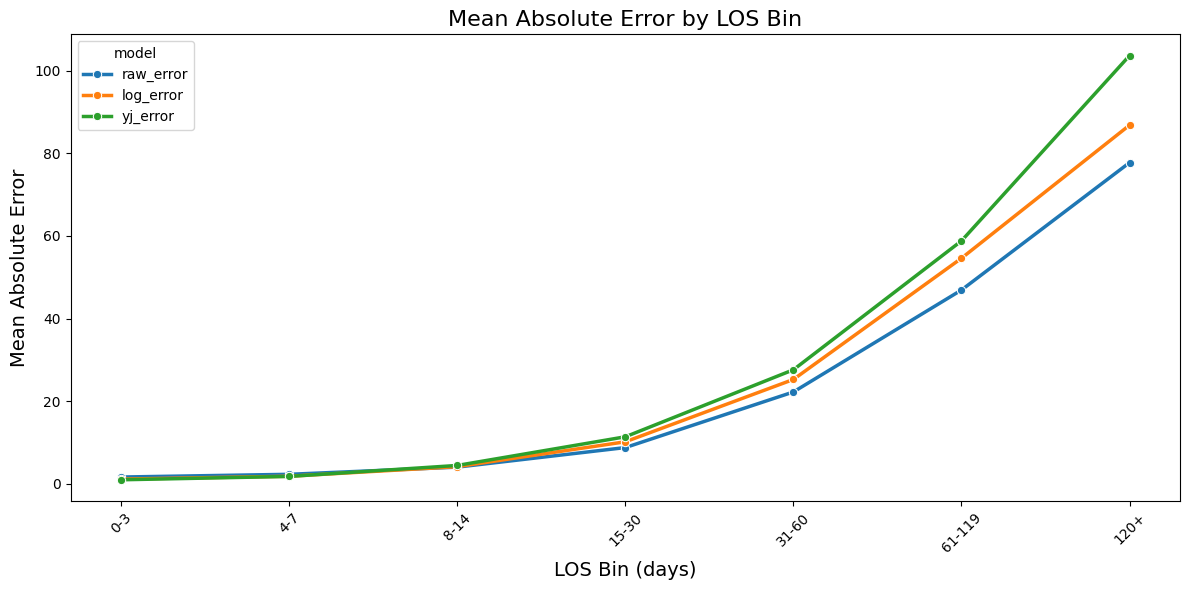

In [ ]:
# Plot errors
import seaborn as sns

# Melt dataframe
plot_df = bin_errors.reset_index().melt(
    id_vars="los_bin",
    value_vars=["raw_error", "log_error", "yj_error"],
    var_name="model",
    value_name="MAE"
    )

plt.figure(figsize=(12,6))
sns.lineplot(
    data=plot_df,
    x="los_bin",
    y="MAE",
    hue="model",
    marker="o",
    linewidth=2.5
)

# Plot
plt.title("Mean Absolute Error by LOS Bin", fontsize=16)
plt.xlabel("LOS Bin (days)", fontsize=14)
plt.ylabel("Mean Absolute Error", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# 7. SAVE MODELS

model_raw.save_model("/content/drive/MyDrive/Sparcs_Datafiles/cb_raw_model.cbm")
model_log.save_model("/content/drive/MyDrive/Sparcs_Datafiles/cb_log_model.cbm")
model_yj.save_model("/content/drive/MyDrive/Sparcs_Datafiles/cb_yj_model.cbm")

joblib.dump(model_raw, "/content/drive/MyDrive/Sparcs_Datafiles/cb_raw_model.pkl")
joblib.dump(model_log, "/content/drive/MyDrive/Sparcs_Datafiles/cb_log_model.pkl")
joblib.dump(model_yj, "/content/drive/MyDrive/Sparcs_Datafiles/cb_yj_model.pkl")

print("Models saved.")


Models saved.
